In [49]:


import random
import math
import numpy as np
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
import matplotlib.pyplot as plt

In [50]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

In [51]:
toolbox = base.Toolbox()
toolbox.register("attr_uniform", random.uniform, -100, 100)
toolbox.register("individual", tools.initRepeat,creator.Individual, toolbox.attr_uniform, 2)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)


In [52]:
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0]**2 + x[1]**2)
    return res,

toolbox.register("evaluate", funcion_objetivo)

In [53]:
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian,mu=0, sigma=5, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=3)


{'='*75}
  Pobl      Mejor x      Mejor y    Fitness        Avg        Std      Min      Max
---------------------------------------------------------------------------
    10     -94.6928     -98.7002   136.7789   136.7789        0.0 136.7789 136.7789
    30     -99.3464     -98.7853   140.1008   140.0666      0.184  139.076 140.1008
    50      99.4752     -99.4716   140.6766   137.8431    19.8347     -1.0 140.6766


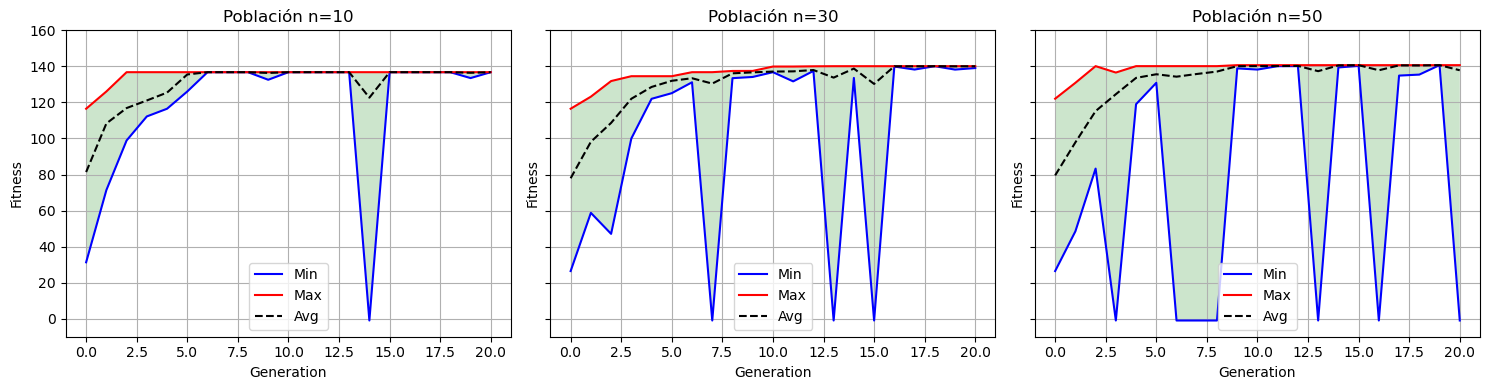

In [54]:
def plot_evolucion(log):
    """Representa la evolución del mejor individuo en cada generación"""
    gen      = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave  = np.array(log.select("avg"), dtype=float)

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave,  "--k")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen, fit_mins, fit_maxs,where=where_mask, facecolor='g', alpha=0.2)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10, 160])
    ax1.legend(["Min", "Max", "Avg"], loc="lower center")
    plt.grid(True)
    plt.savefig("Convergencia.eps", dpi=300)


def main(n_pop=10, n_gen=20, seed=42):
    random.seed(seed)
    CXPB, MUTPB = 0.5, 0.2
    pop = toolbox.population(n=n_pop)
    hof   = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    pop, logbook = algorithms.eaSimple(pop, toolbox,cxpb=CXPB, mutpb=MUTPB, ngen=n_gen,stats=stats, halloffame=hof, verbose=False)
    return hof, logbook


def plot_comparativo(logs, etiquetas):
    """Grafica las curvas de convergencia (max) de cada corrida"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, log, label in zip(axes, logs, etiquetas):
        gen      = np.array(log.select("gen"))
        fit_mins = np.array(log.select("min"), dtype=float)
        fit_maxs = np.array(log.select("max"), dtype=float)
        fit_ave  = np.array(log.select("avg"), dtype=float)

        ax.plot(gen, fit_mins, "b", label="Min")
        ax.plot(gen, fit_maxs, "r", label="Max")
        ax.plot(gen, fit_ave,  "--k", label="Avg")
        ax.fill_between(gen, fit_mins, fit_maxs,where=fit_maxs >= fit_mins,facecolor='g', alpha=0.2)
        ax.set_title(label)
        ax.set_xlabel("Generation")
        ax.set_ylabel("Fitness")
        ax.set_ylim([-10, 160])
        ax.legend(loc="lower center")
        ax.grid(True)

    plt.tight_layout()
    plt.savefig("Convergencia_comparativa.png", dpi=300)
    plt.show()


if __name__ == "__main__":
    configuraciones = [
        {"n_pop": 10,  "label": "Población n=10"},
        {"n_pop": 30,  "label": "Población n=30"},
        {"n_pop": 50,  "label": "Población n=50"},
    ]

    resultados = []
    logs       = []
    etiquetas  = []

    for cfg in configuraciones:
        hof, log = main(n_pop=cfg["n_pop"], n_gen=20)
        best = hof[0]

        # Última generación del logbook
        ultima = {k: log.select(k)[-1] for k in ["avg", "std", "min", "max"]}

        resultados.append({
            "Población" : cfg["n_pop"],
            "Mejor x"   : round(best[0], 4),
            "Mejor y"   : round(best[1], 4),
            "Fitness"   : round(best.fitness.values[0], 4),
            "Avg final" : round(ultima["avg"], 4),
            "Std final" : round(ultima["std"], 4),
            "Min final" : round(ultima["min"], 4),
            "Max final" : round(ultima["max"], 4),
        })
        logs.append(log)
        etiquetas.append(cfg["label"])

    # ── Tabla comparativa ──────────────────────────────────────────
    print("\n{'='*75}")
    print(f"{'Pobl':>6} {'Mejor x':>12} {'Mejor y':>12} {'Fitness':>10} "
          f"{'Avg':>10} {'Std':>10} {'Min':>8} {'Max':>8}")
    print("-" * 75)
    for r in resultados:
        print(f"{r['Población']:>6} {r['Mejor x']:>12} {r['Mejor y']:>12} "
              f"{r['Fitness']:>10} {r['Avg final']:>10} {r['Std final']:>10} "
              f"{r['Min final']:>8} {r['Max final']:>8}")
    print("=" * 75)

    # ── Gráficas de convergencia ───────────────────────────────────
    plot_comparativo(logs, etiquetas)